## Exploratory Data Analysis of Online Food Delivery Ecosystem ft.Zomato.

## AIM
The aim of this project is to analyze restaurant performance and customer preference patterns in an online food delivery ecosystem using Python-based data analytics, in order to identify key factors influencing restaurant ratings, pricing strategies, popularity, and customer engagement.

## EDA Objectives

1. Analyze restaurant performance
2. Understand customer preferences
3. Study pricing patterns
4. Evaluate impact of online services
5. Identify potential market opportunities

## 3. DATA LOADING

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("zomato_cleaned.csv", engine='python' , on_bad_lines='skip')

## 4. DATASET OVERVIEW

In [ ]:
df.head()

,url,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),price_category
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,Medium
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,Medium
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,Medium
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,Low
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,Medium


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33993 entries, 0 to 33992
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          33993 non-null  object 
 1   address                      33993 non-null  object 
 2   name                         33993 non-null  object 
 3   online_order                 33993 non-null  object 
 4   book_table                   33993 non-null  object 
 5   rate                         33993 non-null  float64
 6   votes                        33993 non-null  int64  
 7   location                     33993 non-null  object 
 8   rest_type                    33866 non-null  object 
 9   dish_liked                   18980 non-null  object 
 10  cuisines                     33987 non-null  object 
 11  approx_cost(for two people)  33993 non-null  float64
 12  reviews_list                 33993 non-null  object 
 13  menu_item       

Insight : The dataset contains 33993 valid restaurant records after cleaning and error handling (data pre-processing step).Key numerical variables have been successfully converted into appropriate data types for quantitative analysis.Also a new column "price_category is created to categorize restaurant into pricing segments.

## 5. STATISTICAL SUMMARY

In [ ]:
df.describe()

,rate,votes,approx_cost(for two people)
count,33993.000000,33993.000000,33993.000000
mean,3.696323,323.706645,581.812932
std,0.432763,785.531972,436.796365
min,1.800000,0.000000,40.000000
25%,3.400000,21.000000,300.000000
50%,3.700000,71.000000,450.000000
75%,4.000000,261.000000,700.000000
max,4.900000,16345.000000,6000.000000


Insights : The average restaurant rating is around 3.7. indicating generally positive customer satisfaction across the platform.There is a large variation in customer engagement.Most restaurants fall in the low to mid price range,costing between 300-700 rupees for two people.

## 6. MISSING VALUE ANALYSIS

In [ ]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,127
dish_liked,15013


Insight : The dataset has been cleaned in the data pre-processing phase by deleting duplicates,removing missing columns and fixing datatype.The dataset shows no misssing values in key variables such as rating,cost,location,and votes.

## 7. UNIVARIATE ANALYSIS

      7.1 Analysis: Rating Distribution

      Objective - To understand how restaurant ratings are distributed.

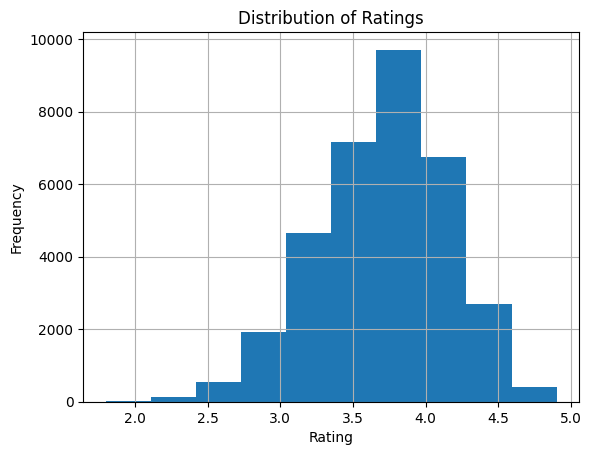

In [ ]:
import matplotlib.pyplot as plt

df['rate'].hist()
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

     7.2 Analysis : Price Category Distribution

     Objective : To understand the distribution of restaurants across price ranges

In [ ]:
df['price_category'].value_counts()

,count
price_category,
Low,20545
Medium,9772
High,3254
Luxury,422


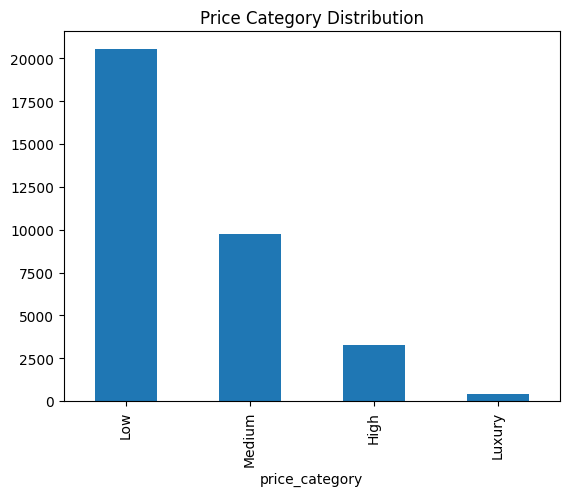

In [ ]:
df['price_category'].value_counts().plot(kind='bar')
plt.title("Price Category Distribution")
plt.show()

Insight : The majority of restaurants have ratings between 3.5 and 4.2 indicating generally positive customer satisfaction.Very few restaurants have low ratings below 3.0 and also very few restaurants have ratings above 4.5.The distribution is approximately normal which showes a balanced customer feedback with limited ratings.

The market follows a pyramid structure with a large base of low-cost restaurants and a very small luxury segment.High end and luxury restaurants are comparitively fewer, indicating that food delivery ecosystem mainly centers to budgetfriendly customers.

## 8. BIVARIATE ANALYSIS

     8.1 Analysis : Cost vs Rating

     Objective : To analyze whether higher-priced restaurants have better ratings.

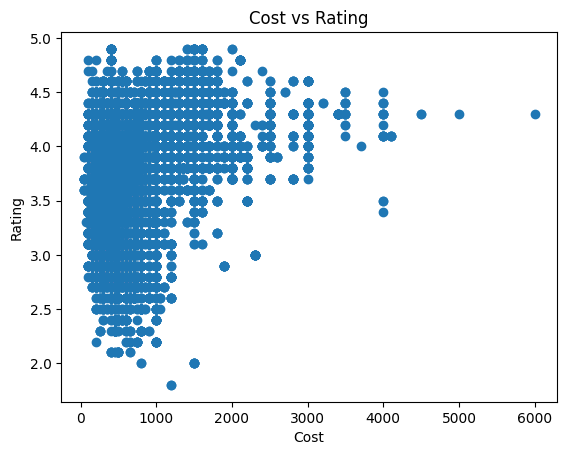

In [ ]:
plt.scatter(df['approx_cost(for two people)'], df['rate'])
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.title("Cost vs Rating")
plt.show()

     8.2 Analysis : Impact of Online Ordering

     Objective : To evaluate whether online ordering affects restaurant ratings.

In [ ]:
df.groupby('online_order')['rate'].mean()

,rate
online_order,
No,3.649914
Yes,3.718666


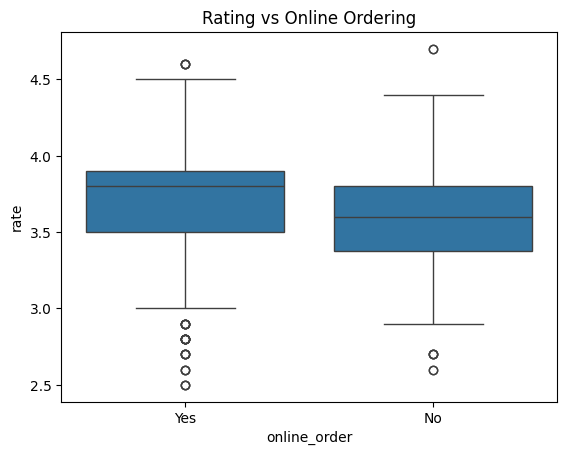

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='online_order', y='rate', data=df)
plt.title("Rating vs Online Ordering")
plt.show()

Insight : There is no strong relashionship between cost and rating.Higher-priced restaurants do not necessarily receive better ratings.Restaurants in all price ranges are capable of getting high ratings.Majority of restaurants are in low to mid price range ,which can mean market has affordable dinning options and quality is not limited to expensive establishments.

Restaurants that have online ordering have slighly higher average ratings compared to those that do not have.Online delivery brings customer convinience,that can positively influence customer satisfaction and ratings.

The boxplot analysis shows online ordering restaurants have slighly higher median rating and also there is a better consistency in online-order restaurants suggesting stable service and customer experience.However,both categories exhibit similiar rating ranges,indicating that while online ordering provides a competitive advantage in convenience,it is not the sole factor influencing restaurant quality.

     8.3 Analysis : Votes vs Ratings
     Objective : To analyze reashionship between popularity and ratings

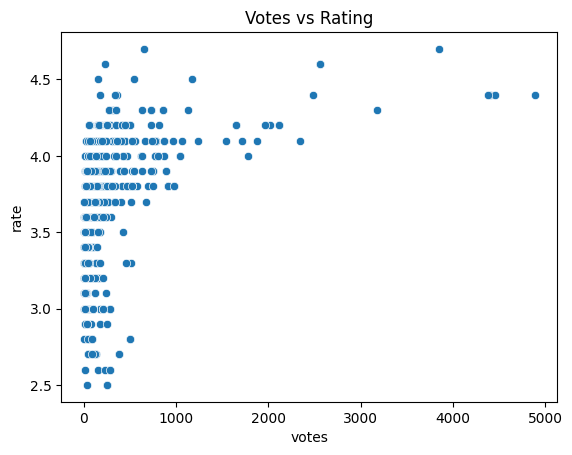

In [3]:
sns.scatterplot(x='votes' , y='rate' , data=df)
plt.title("Votes vs Rating")
plt.show()

Insight : There is a moderate positive relashionship between votes and ratings.where highly rated restaurants tend to recieve more votes.However,most restaurantsnhave relatively low vote counts,and lower-vote restaurants display a wide range of ratings.This indicates that while quality contributes to popularity,other factors such as visiblity and customer reach also play a role.

## 9. MULTIVARIATE ANALYSIS

     9.1 Analysis : Location + Price + Rating

     Objective : To understand how location and pricing together affect ratings.

In [ ]:
df.groupby(['location','price_category'])['rate'].mean().head(10)

location           price_category
BTM                High              4.145313
                   Low               3.553403
                   Medium            3.596521
Banashankari       High              3.986667
                   Low               3.595219
                   Medium            3.750885
Banaswadi          High              3.541176
                   Low               3.498324
                   Medium            3.460825
Bannerghatta Road  High              4.057895
Name: rate, dtype: float64

Insight : The analysis shows that restaurant perfomances varies across both location and price catgegory.Overall the output highlights that location plays a key role in determing the success of the restaurants, sometimes even more than pricing ,so pricing strategies should be adapted accordingly.

## 10. GROUPBY ANALYSIS

    10.1 Analysis : Top Performing Locations

     Objective : To identify locations with the highest average ratings.

In [ ]:
df.groupby(['location','price_category'])['rate'].mean().head(10)

location           price_category
BTM                High              4.145313
                   Low               3.553403
                   Medium            3.596521
Banashankari       High              3.986667
                   Low               3.595219
                   Medium            3.750885
Banaswadi          High              3.541176
                   Low               3.498324
                   Medium            3.460825
Bannerghatta Road  High              4.057895
Name: rate, dtype: float64

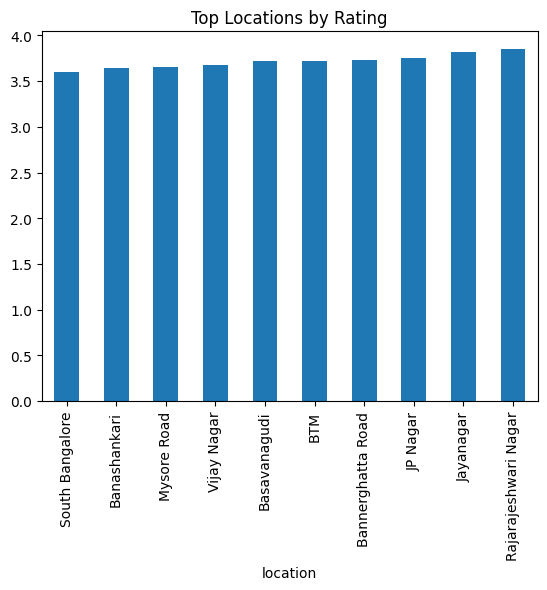

In [7]:
df.groupby('location')['rate'].mean().sort_values().tail(10).plot(kind='bar')
plt.title("Top Locations by Rating")
plt.show()

     10.2 Analysis : Pricing Strategy Effectiveness

     Objective : To evaluate how pricing categories influence ratings.

In [ ]:
df.groupby('price_category')['rate'].mean()

,rate
price_category,
High,4.115704
Low,3.588980
Luxury,4.113033
Medium,3.764357


     10.3 Pricing vs Rating
     Objective : To evaluate effectiveness of pricing strategy.

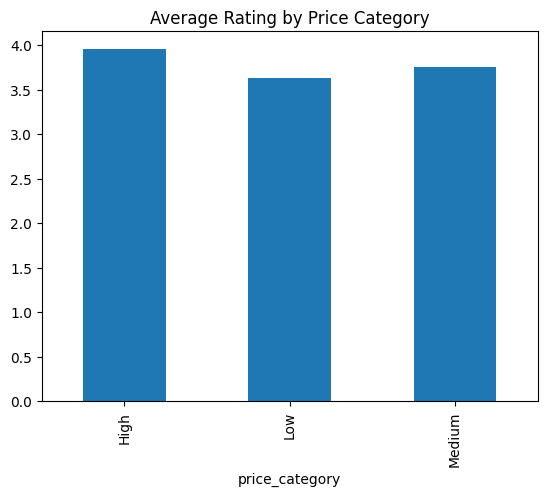

In [8]:
df.groupby('price_category')['rate'].mean().plot(kind='bar')
plt.title("Average Rating by Price Category")
plt.show()

Insight : All top locations have consistently high ratings.Rajarajeshwari Nagar,Jayanagar and JP Nagar have the highest average ratings indicating strong restaurant perfomance and customer satisfaction.The differences between these top locations are relatively small,suggesting that multiple areas serve as high-quality food hubs.Overall, the results highlight a competitive restaurant ecosystm where several locations consistently maintain high standards.

Certain locations have significantly higher average ratings indicating better restaurant perfomance and higher customer satisfaction.BTM is a high performing hotspot suggesting a strong circle of highly rated restaurants.Also location strongly influences restaurant success.

There is a similarity in ratings between high and luxury categories showing that increasing price beyond a certain level does not significantly improve ratings.While pricing influences ratings,it is not the sole determinant.

## 11. PIVOT TABLE ANALYSIS

Analysis : Location vs Price Category

Objective : To compare ratings across different locations and price categories.

In [ ]:
pd.pivot_table(
    df,
    values='rate',
    index='location',
    columns='price_category',
    aggfunc='mean'
)

price_category,High,Low,Luxury,Medium
location,,,,
BTM,4.145313,3.553403,NaN,3.596521
Banashankari,3.986667,3.595219,NaN,3.750885
Banaswadi,3.541176,3.498324,NaN,3.460825
Bannerghatta Road,4.057895,3.451820,NaN,3.593122
Basavanagudi,2.700000,3.661591,3.700000,3.757258
...,...,...,...,...
West Bangalore,NaN,3.400000,NaN,NaN
Whitefield,3.927632,3.467368,4.371429,3.641401
Wilson Garden,NaN,3.500000,NaN,3.632258


## 12. CORRELATION ANALYSIS

Analysis : Relashionship Between Variables

Objective : To measure relationships between ratings,votes and cost.

In [ ]:
df[['rate','votes','approx_cost(for two people)']].corr()

,rate,votes,approx_cost(for two people)
rate,1.000000,0.432867,0.365311
votes,0.432867,1.000000,0.365505
approx_cost(for two people),0.365311,0.365505,1.000000


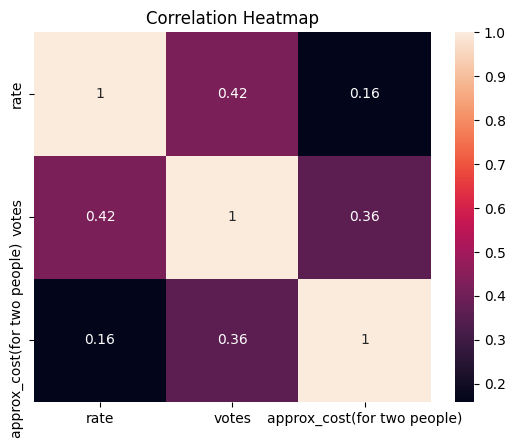

In [9]:
sns.heatmap(df[['rate','votes','approx_cost(for two people)']].corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

Insight : The correlation analysis shows a moderate positive relashionship between ratings and votes,showing that higher-rated restaurants tend to be more popular.Cost and votes shows a weak relashionship.None of the variables shows a strong correlations,indicating that restaurant perfomance depends on multiple factors beyond just cost,rating or votes.

## 13. OUTLIER DETECTION

Analysis : Cost Outliers

Objective : To identify unusually high or low pricing.

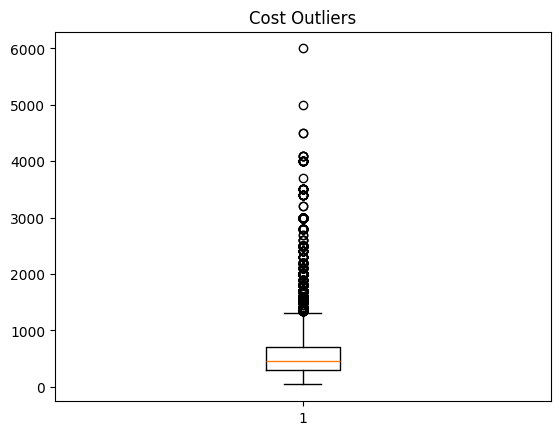

In [ ]:
plt.boxplot(df['approx_cost(for two people)'])
plt.title("Cost Outliers")
plt.show()

Insight : The majority of restaurants are within the low to mid-price range and typical cost for two people is around 45-500 rupees indicating affordable dining dominates and also market caters to budget friendly/conscious customers.There are also many high cot outliers representing premium and luxury restaurants that are priced above market range.Also the luxury dining is limited but consists of extremely high priced restaurants indicating a niche but premium market. The restaurant ecosystem shows significant pricing difference,with a large base of affordableoptions and a small number of high end establishments.

## 14. Customer Preference Analysis

Analysis : Customer Preference Analysis

Objective : To understand popular restaurant types.

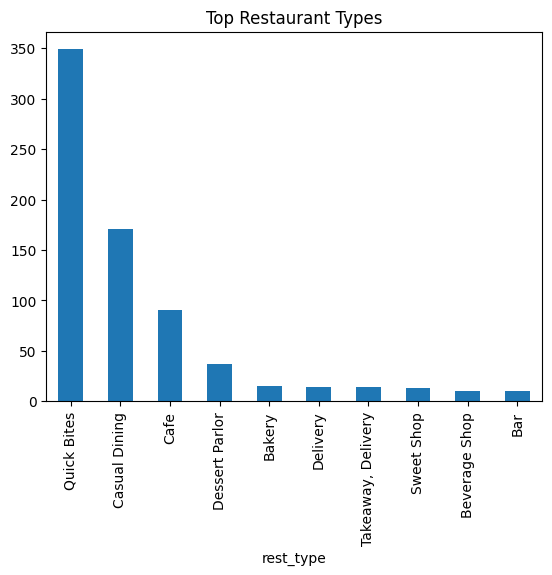

In [10]:
df['rest_type'].value_counts().head(10).plot(kind="bar")
plt.title("Top Restaurant Types")
plt.show()

Insight : The distribution of restaurant types shows that Quick Bites dominate the market, followed by Casual Dining and Cafes indicating strong customer preference for convenient and affordable dining options.Dessert parlors,bakeries, and bars are comparitively smaller,suggesting they cater to niche demands.Overall,the food delivery ecosystem is driven primarily by fast-service and casual dining formats.

## 15. KEY FINDINGS



*   Most restaurants have ratings between 3.5–4.2, indicating generally high customer satisfaction.
*  The market is dominated by low and mid-range restaurants, showing strong demand for affordable dining.
*   Higher-priced restaurants have slightly better ratings, but price is not a strong determinant of quality.
*   There is a moderate relationship between ratings and votes, meaning better-rated restaurants tend to be more popular.
*   Restaurants offering online ordering have slightly higher ratings, highlighting the importance of convenience.
*   Restaurant performance varies significantly by location, with some areas consistently outperforming others.
*   The effectiveness of pricing strategies differs across locations, requiring location-based decision-making.
*   The market follows a pyramid structure, with many low-cost restaurants and very few luxury establishments.
*   A small number of high-cost outliers indicate a niche premium segment in the market.
*   The food delivery ecosystem is driven primarily by fast-service and casual dining formats.
*   Customer satisfaction (ratings) is more closely linked to popularity (votes) than to pricing,highlighting that quality and customer experience matter more than cost.
*   List item




*   Overall, restaurant success depends on multiple factors beyond pricing, including quality, location, and customer experience.









